In [1]:
# Choosing optimal k for K-Means: Elbow Method + Silhouette Score

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -------------------------------------------------------------
# 1) Create synthetic clustering data
# -------------------------------------------------------------
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

In [2]:
# -------------------------------------------------------------
# 2) Compute metrics for different k values
# -------------------------------------------------------------
k_values = range(2, 15)

wcss = []           # Within-cluster sum of squares (for Elbow)
sil_scores = []     # Silhouette scores

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    wcss.append(kmeans.inertia_)                # Elbow metric
    sil_scores.append(silhouette_score(X, labels))

wcss

[9416.214004352274,
 2110.4125218953295,
 564.9141808210252,
 512.3903339109634,
 460.3079031235533,
 408.9473812641575,
 360.8214343877638,
 325.37268835521905,
 291.5608624106775,
 261.1127818951174,
 233.7657418550425,
 219.5475170972828,
 203.65412799725823]

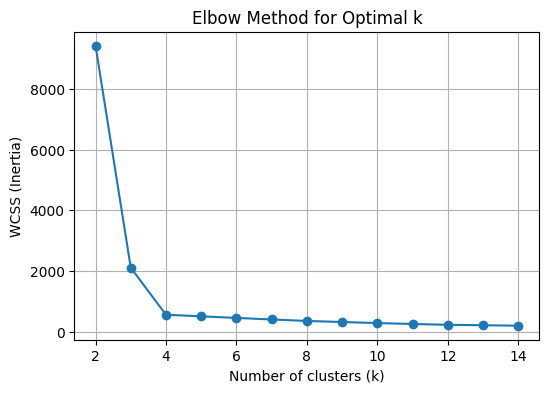

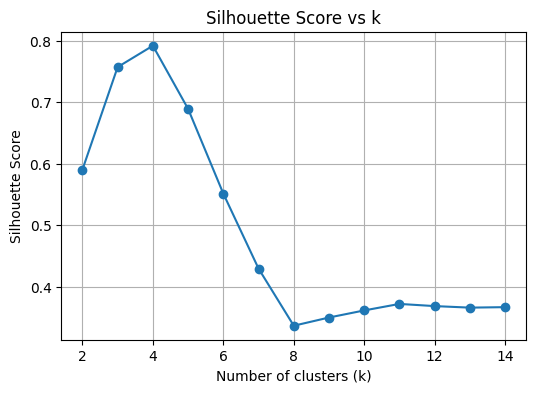

In [3]:
# -------------------------------------------------------------
# 3) Plot Elbow Method
# -------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(k_values, wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

# -------------------------------------------------------------
# 4) Plot Silhouette Score
# -------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(k_values, sil_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.grid(True)
plt.show()